Esse notebook trata de uma Regressão que prevê valores de casas em Boston.

Bibliotecas

In [ ]:
# Tratamento dos dados
!pip install category_encoders
import pandas as pd
import numpy as np

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer  # pipeline com colunas de tipos diferentes
from sklearn.impute import SimpleImputer  # missing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # escala
from sklearn.preprocessing import OneHotEncoder

# category_encoders: importar o pacote inteiro é mais robusto
import category_encoders as ce  # use ce.TargetEncoder(), ce.OneHotEncoder()

# seleção de features — escolha a função de score conforme seu problema
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Modelagem
import lightgbm as lgb

# Configurações gerais
import warnings
warnings.filterwarnings("ignore")



In [ ]:
# Organizando a base de dados

column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO','B','LSTAT','MEDV',]

data = pd.read_csv("/content/drive/MyDrive/DataBase/Boston_house_pred.csv", header = None, delimiter = r"\s+", names = column_names)
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
# Verificando tamanho
data.shape

(506, 14)

In [ ]:
# Possui missing?
data.isna().mean()

# Taxa de 0% faltante

,0
CRIM,0.0
ZN,0.0
INDUS,0.0
CHAS,0.0
NOX,0.0
RM,0.0
AGE,0.0
DIS,0.0
RAD,0.0
TAX,0.0


Aqui seria feita a análise exploratória, mas os dados já estão limpos

Modelo Preditivo


In [ ]:
# Todas as variáveis dessa base são numéricos
# Criando uma categórica sobre CHAS, se é perto ou não de um rio

data["CHAS"] = data["CHAS"].map({1: "Yes", 0: "No"})
data["CHAS"].value_counts()

,count
CHAS,
No,471
Yes,35


In [ ]:
categorical_columns = data.select_dtypes(exclude="number").columns.to_list()
numerical_columns = data.select_dtypes(include="number").columns.to_list()

In [ ]:
data[categorical_columns].head()
# Separado em apenas variáveis categóricas

,CHAS
0,No
1,No
2,No
3,No
4,No


In [ ]:
# Apenas variáveis numéricas
data[numerical_columns].head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
# Tirar também o Target
[feature for feature in numerical_columns if feature != "MEDV"]
target = "MEDV"

In [ ]:
# FEATURES!
X = data[numerical_columns + categorical_columns]
y = data[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (354, 14)
X_test: (152, 14)
y_train: (354,)
y_test: (152,)


In [ ]:
lgb_model = lgb.LGBMRegressor()

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_regression, k=10)),
    ("model", lgb_model)
])

pipeline.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 10
[LightGBM] [Info] Start training from score 23.015819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CRIM', 'ZN', 'INDUS', 'NOX',
                                                   'RM', 'AGE', 'DIS', 'RAD',
                                                   'TAX', 'PTRATIO', 'B',
                                                   'LSTAT', 'MEDV']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder())]),
                                                  ['CHAS'])])),
                ('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x7a99667a0cc0>)),
                ('model', LGBMRegressor())])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 11.7525
Mean Absolute Error (MAE): 2.3137
Root Mean Squared Error (RMSE): 3.4282
R-squared (R2): 0.8423


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")


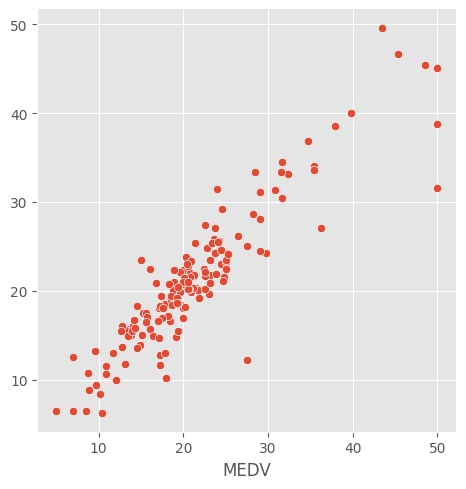

In [ ]:
sns.relplot(x=y_test, y=y_pred, kind="scatter")
plt.show()

